In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive/emotion_project/data/processed

X_test.npy  X_train.npy  y_test.npy  y_train.npy


In [3]:
import numpy as np

X_train = np.load("/content/drive/MyDrive/emotion_project/data/processed/X_train.npy")
X_test = np.load("/content/drive/MyDrive/emotion_project/data/processed/X_test.npy")

y_train = np.load("/content/drive/MyDrive/emotion_project/data/processed/y_train.npy")
y_test = np.load("/content/drive/MyDrive/emotion_project/data/processed/y_test.npy")

print(X_train.shape, X_test.shape)

(333447, 50) (83362, 50)


# Deep Learning Libraries

In [4]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.layers import Attention
from tensorflow.keras.optimizers import Adam

# Model Parameters

In [5]:
MAX_WORDS = 20000
MAX_LEN = 50
EMBED_DIM = 128

# Attention Model

In [12]:
from tensorflow.keras.layers import GlobalAveragePooling1D

input_layer = Input(shape=(MAX_LEN,))

embedding = Embedding(input_dim=MAX_WORDS, output_dim=EMBED_DIM)(input_layer)

bilstm = Bidirectional(LSTM(64, return_sequences=True))(embedding)

attention = Attention()([bilstm, bilstm])

pool = GlobalAveragePooling1D()(attention)

drop = Dropout(0.5)(pool)

dense = Dense(64, activation='relu')(drop)

output = Dense(6, activation='softmax')(dense)

attention_model = Model(inputs=input_layer, outputs=output)

attention_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

# Compile the Model

In [13]:
attention_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [14]:
attention_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 50, 128)   │  2,560,000 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 50, 128)   │     98,816 │ embedding_3[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_3         │ (None, 50, 128)   │          0 │ bidirectional_3[… │
│ (Attention)         │                   │            │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention_3[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 6)         │        390 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,667,462 (10.18 MB)

 Trainable params: 2,667,462 (10.18 MB)

 Non-trainable params: 0 (0.00 B)

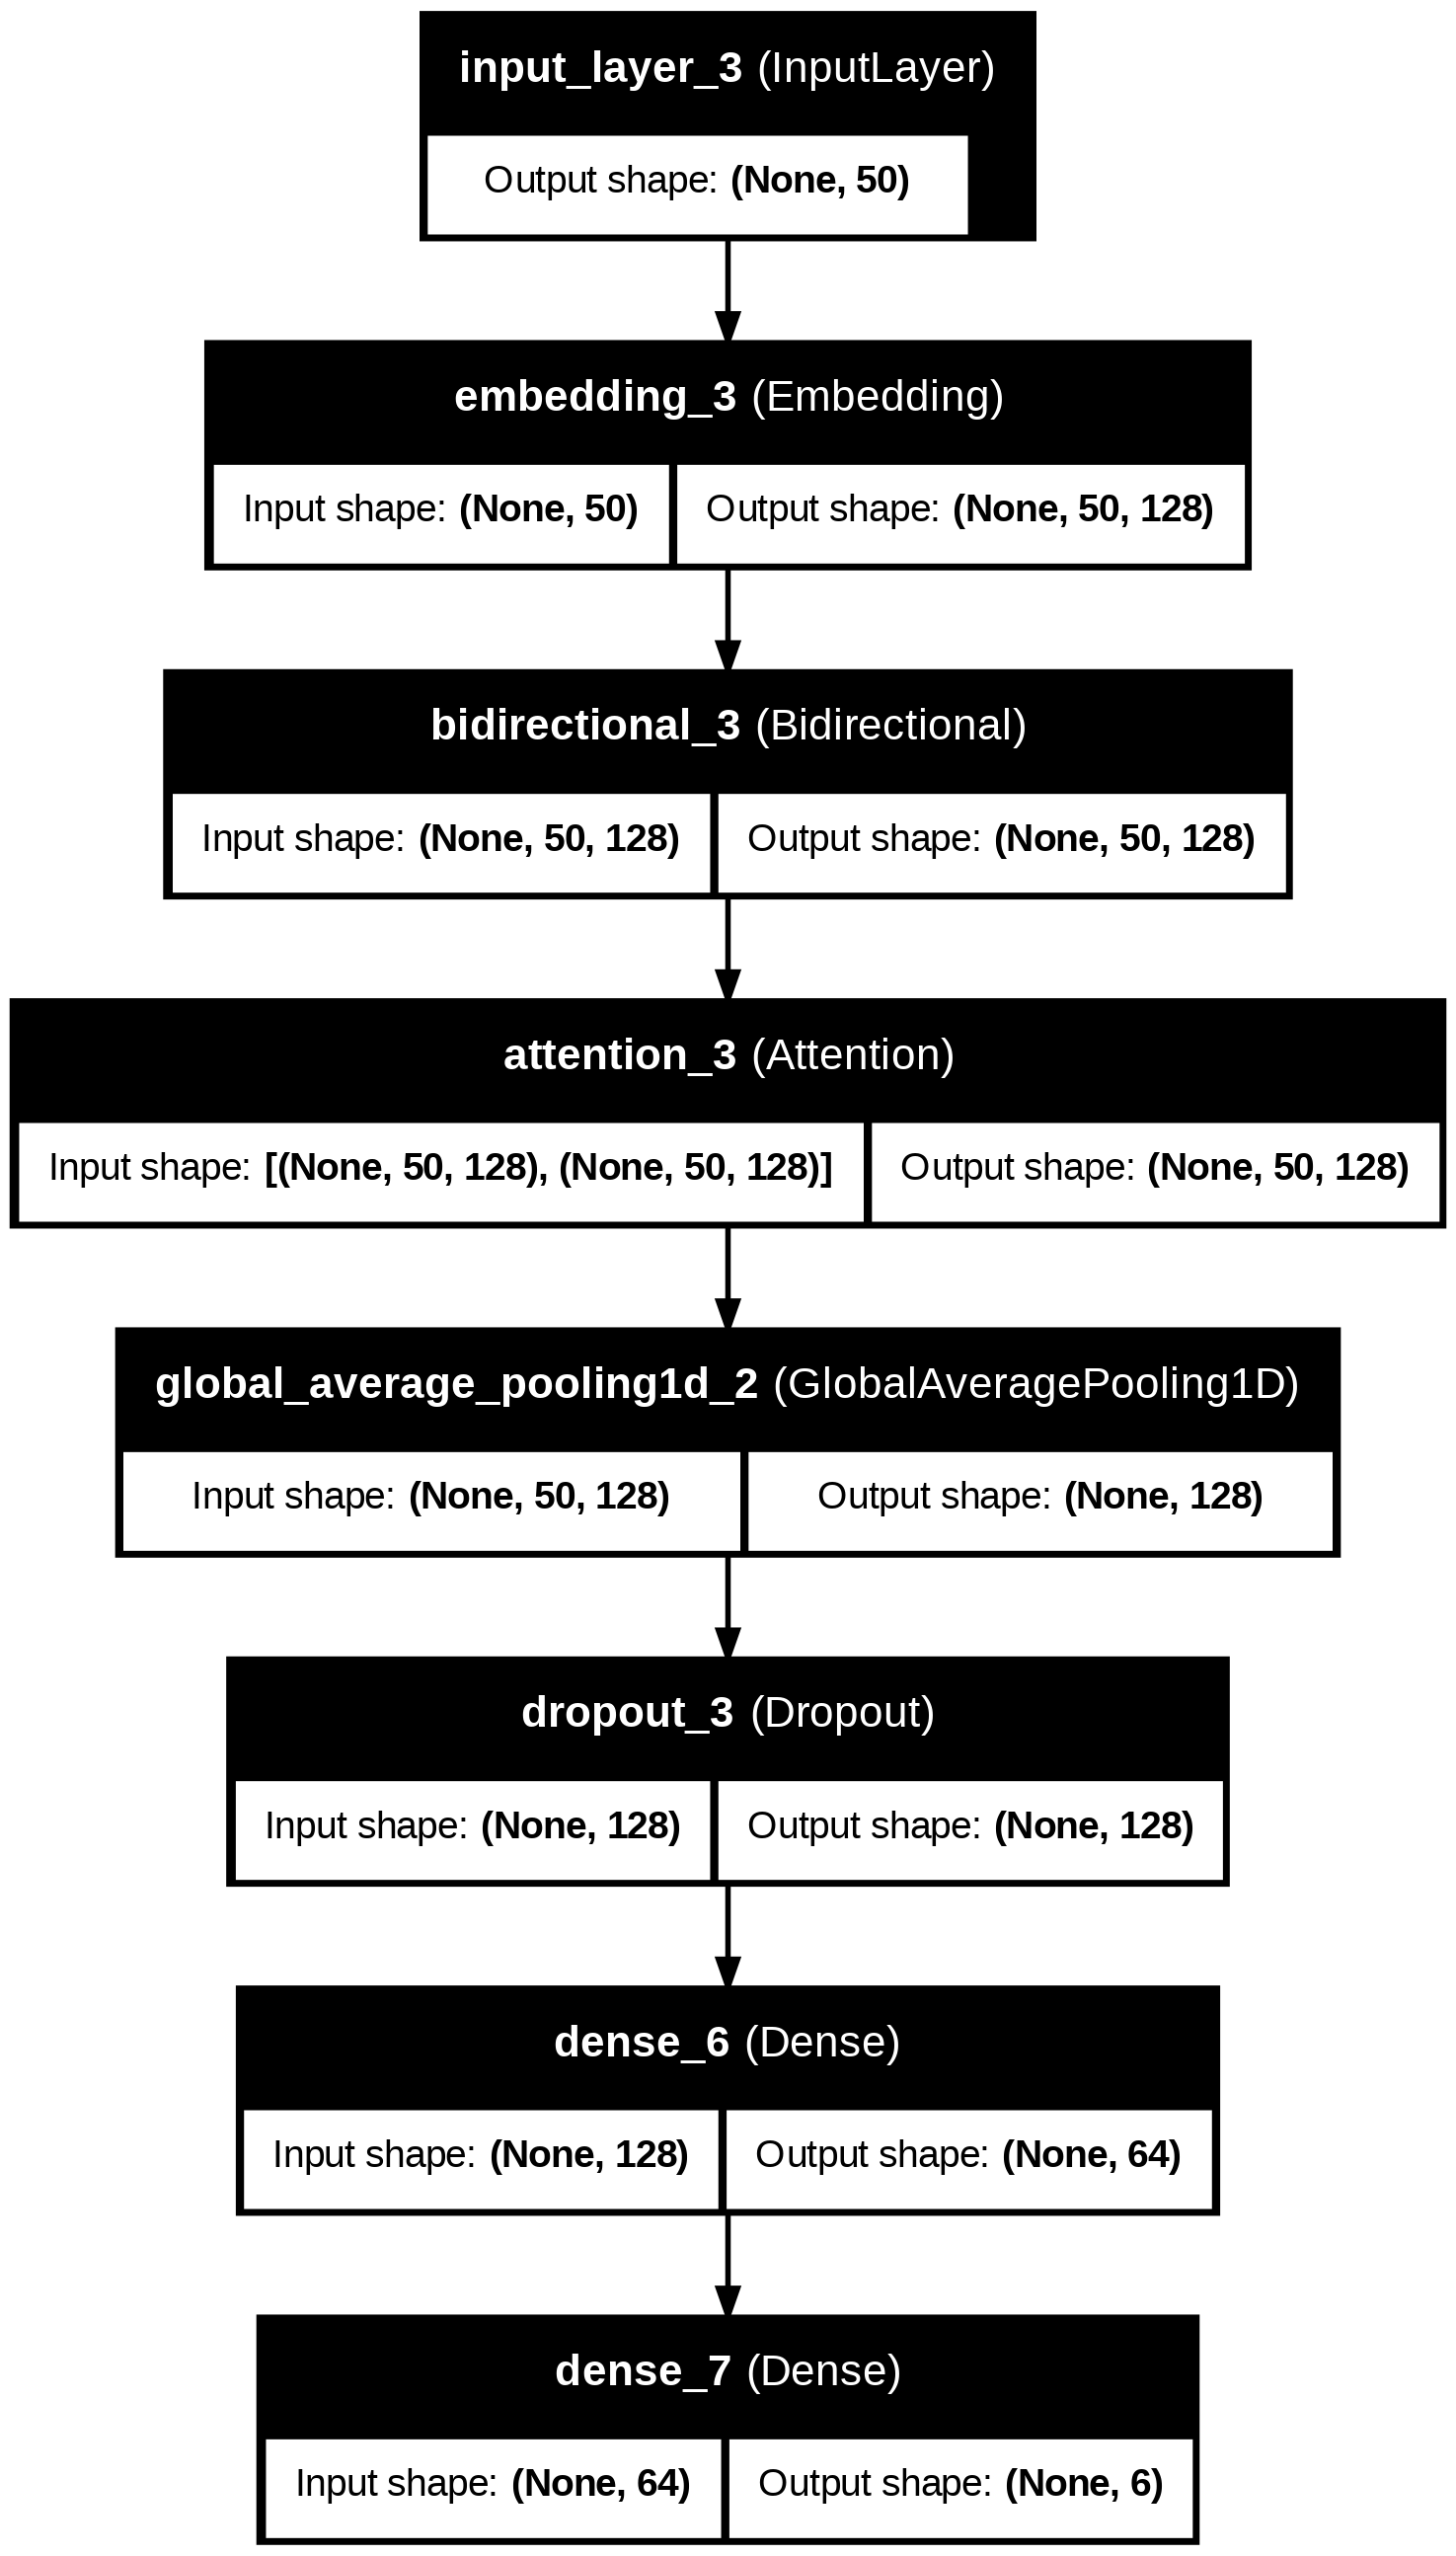

In [15]:
from tensorflow.keras.utils import plot_model

plot_model(
    attention_model,
    to_file="/content/drive/MyDrive/emotion_project/results/attention_model_architecture.png",
    show_shapes=True,
    show_layer_names=True
)

# Training

In [16]:
history_att = attention_model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/3
2345/2345 ━━━━━━━━━━━━━━━━━━━━ 651s 275ms/step - accuracy: 0.6909 - loss: 0.7981 - val_accuracy: 0.9307 - val_loss: 0.1198
Epoch 2/3
2345/2345 ━━━━━━━━━━━━━━━━━━━━ 648s 276ms/step - accuracy: 0.9363 - loss: 0.1205 - val_accuracy: 0.9321 - val_loss: 0.1065
Epoch 3/3
2345/2345 ━━━━━━━━━━━━━━━━━━━━ 647s 276ms/step - accuracy: 0.9419 - loss: 0.1018 - val_accuracy: 0.9337 - val_loss: 0.1047


# Test Model

In [17]:
loss_att, acc_att = attention_model.evaluate(X_test, y_test)

print("Attention Test Accuracy:", acc_att)

2606/2606 ━━━━━━━━━━━━━━━━━━━━ 66s 25ms/step - accuracy: 0.9331 - loss: 0.1049
Attention Test Accuracy: 0.9328950643539429


# Prediction

In [18]:
import numpy as np

y_pred_att = attention_model.predict(X_test)

y_pred_att = np.argmax(y_pred_att, axis=1)

2606/2606 ━━━━━━━━━━━━━━━━━━━━ 63s 24ms/step


# Classification Report

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_att))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97     24504
           1       0.97      0.93      0.95     28247
           2       0.79      0.91      0.84      6853
           3       0.90      0.98      0.94     11339
           4       0.88      0.91      0.89      9376
           5       0.85      0.73      0.79      3043

    accuracy                           0.93     83362
   macro avg       0.90      0.90      0.90     83362
weighted avg       0.94      0.93      0.93     83362



# Confustion Matrix

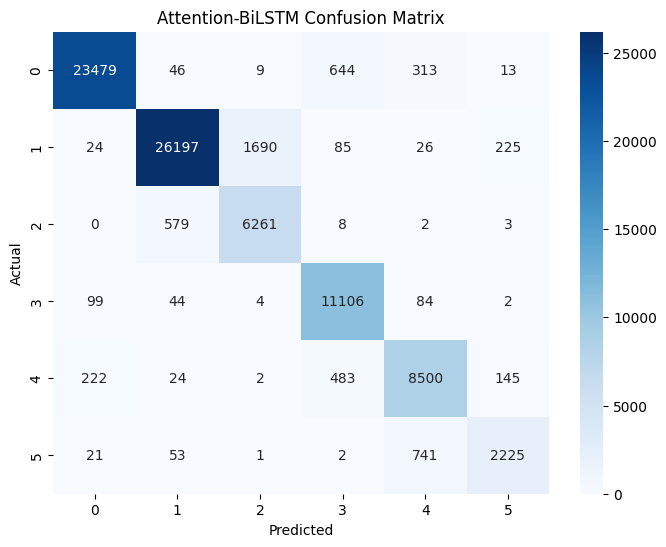

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_att = confusion_matrix(y_test, y_pred_att)

plt.figure(figsize=(8,6))
sns.heatmap(cm_att, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Attention-BiLSTM Confusion Matrix")

plt.savefig("/content/drive/MyDrive/emotion_project/results/attention_confusion_matrix.png")
plt.show()

# Classification Report

In [23]:
report_att = classification_report(y_test, y_pred_att)

with open("/content/drive/MyDrive/emotion_project/results/attention_classification_report.txt", "w") as f:
    f.write(report_att)

# Accuracy Graph

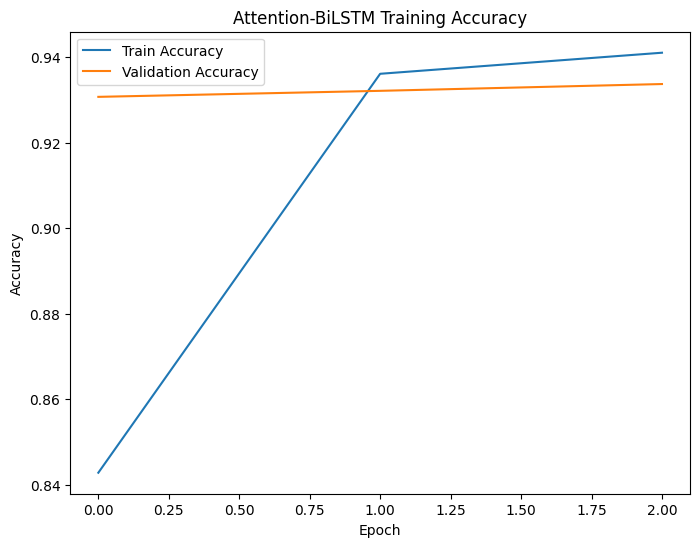

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(history_att.history['accuracy'], label='Train Accuracy')
plt.plot(history_att.history['val_accuracy'], label='Validation Accuracy')

plt.title("Attention-BiLSTM Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("/content/drive/MyDrive/emotion_project/results/attention_training_accuracy.png")

plt.show()

# Loss Graph

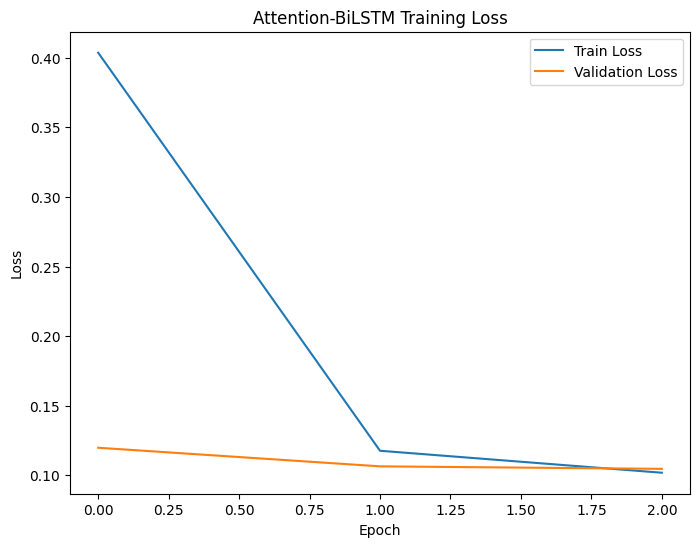

In [26]:
plt.figure(figsize=(8,6))

plt.plot(history_att.history['loss'], label='Train Loss')
plt.plot(history_att.history['val_loss'], label='Validation Loss')

plt.title("Attention-BiLSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("/content/drive/MyDrive/emotion_project/results/attention_loss_curve.png")

plt.show()

In [27]:
attention_model.save("/content/drive/MyDrive/emotion_project/models/attention_bilstm_model.keras")